<a href="https://colab.research.google.com/github/pachterlab/cellsweep/blob/main/benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# try:
#     from cellsweep import denoise_count_matrix
# except ImportError:
#     print("cellsweep not found, installing...")
#     !pip install -U -q cellsweep[analysis]

In [2]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from cellsweep import denoise_count_matrix
import cellsweep.utils as cs_utils
import scipy.sparse as sp

cellsweep_dir = os.path.dirname(os.path.abspath(""))
rver_docker_workspace = "/home/ruser/work/cellsweep"

# Compare technologies

In [3]:
dataset_name = "smartseq_10x"  # options: parse_10x, smartseq_10x
verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = False  # overwrite existing files
threads = 32  # for cellsweep and CellBender (if use_cuda=False)
docker = "podman"  # "docker" or "podman" - if podman, then run `sudo setenforce 0` to disable SELinux enforcement before the podman commands

In [ ]:
data_dir = os.path.join(cellsweep_dir, "notebooks", "data", dataset_name)
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellsweep_dir, "notebooks", "output", dataset_name)
os.makedirs(out_dir, exist_ok=True)

adata_10x_url, adata_parse_url, adata_smartseq_url = None, None, None
adata_path_raw_10x, adata_path_raw_parse, adata_path_raw_smartseq = None, None, None

adata_path_raw_smartseq = os.path.join(data_dir, "adata_smartseq_raw.h5ad")

technology_to_adata_raw, technology_to_adata_raw_path = {}, {}
if dataset_name == "parse_10x":
    technologies = ["10x", "parse"]
    
    adata_10x_url = "https://caltech.box.com/shared/static/g03q46wpr5uj81gqp0dh3dyy02zw200e.h5ad"
    adata_parse_url = "https://caltech.box.com/shared/static/4bai2qfe7xk2956ug1t7bpdw0q6tspie.h5ad"

    adata_path_raw_10x = os.path.join(data_dir, "adata_10x_raw.h5ad")
    adata_path_raw_parse = os.path.join(data_dir, "adata_parse_raw.h5ad")

    if not os.path.exists(adata_path_raw_10x):
        !wget -O {adata_path_raw_10x} {adata_10x_url}

    if not os.path.exists(adata_path_raw_parse):
        !wget -O {adata_path_raw_parse} {adata_parse_url}

    technology_to_adata_raw_path["10x"] = adata_path_raw_10x
    technology_to_adata_raw_path["parse"] = adata_path_raw_parse

    technology_to_adata_raw["10x"] = ad.read_h5ad(adata_path_raw_10x)
    technology_to_adata_raw["parse"] = ad.read_h5ad(adata_path_raw_parse)

    technology_to_umi_cutoff = {
        "10x": 300,
        "parse": 200,
    }
    technology_to_leiden_resolution = {
        "10x": 2.0,
        "parse": 2.5
    }

elif dataset_name == "smartseq_10x":  # https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE132044
    technologies = ["10x", "smartseq"]

    adata_path_raw_10x = os.path.join(data_dir, "10xv3_gene.h5ad")
    adata_path_raw_smartseq = os.path.join(data_dir, "smartseq_gene.h5ad")

    if not os.path.exists(adata_path_raw_10x) or not os.path.exists(adata_path_raw_smartseq):
        matrix_path = os.path.join(data_dir, "GSE132044_mixture_hg19_mm10_count_matrix.mtx.gz")
        cell_path = os.path.join(data_dir, "GSE132044_mixture_hg19_mm10_cell.tsv.gz")
        gene_path = os.path.join(data_dir, "GSE132044_mixture_hg19_mm10_gene.tsv.gz")
        
        if not os.path.exists(matrix_path):
            !wget -O {matrix_path} "https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE132044&format=file&file=GSE132044%5Fmixture%5Fhg19%5Fmm10%5Fcount%5Fmatrix%2Emtx%2Egz"
        if not os.path.exists(cell_path):
            !wget -O {cell_path} "https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE132044&format=file&file=GSE132044%5Fmixture%5Fhg19%5Fmm10%5Fcell%2Etsv%2Egz"
        if not os.path.exists(gene_path):
            !wget -O {gene_path} "https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE132044&format=file&file=GSE132044%5Fmixture%5Fhg19%5Fmm10%5Fgene%2Etsv%2Egz"

        adata = sc.read_mtx(matrix_path)
        adata = adata.T

        genes = pd.read_csv(gene_path, header=None, sep="\t")
        adata.var_names = genes[0].values

        barcodes = pd.read_csv(cell_path, header=None, sep="\t")
        adata.obs_names = barcodes[0].values

        adata.obs[["mixture", "protocol", "plate_well"]] = (
            adata.obs.index
            .to_series()
            .str.split(".", expand=True)
        )

        adata_smartseq = adata[adata.obs['protocol'] == 'Smart-seq2'].copy()
        adata_10x = adata[adata.obs['protocol'] == '10x-Chromium-v2'].copy()

        # save
        adata_smartseq.write_h5ad(adata_path_raw_smartseq)
        adata_10x.write_h5ad(adata_path_raw_10x)

    # if not os.path.exists(adata_path_raw_10x):
    #     !wget -O {adata_path_raw_10x} {adata_10x_url}

    # if not os.path.exists(adata_path_raw_smartseq):
    #     !wget -O {adata_path_raw_smartseq} {adata_smartseq_url}

    technology_to_adata_raw_path["10x"] = adata_path_raw_10x
    technology_to_adata_raw_path["smartseq"] = adata_path_raw_smartseq

    technology_to_adata_raw["10x"] = ad.read_h5ad(adata_path_raw_10x)
    technology_to_adata_raw["smartseq"] = ad.read_h5ad(adata_path_raw_smartseq)

    technology_to_umi_cutoff = {
        "10x": None,
        "smartseq": None,
    }
    technology_to_leiden_resolution = {
        "10x": 1.0,
        "smartseq": 1.0
    }
else:
    raise ValueError(f"dataset_name {dataset_name} not recognized.")

technology0, technology1 = technologies[0], technologies[1]

## Knee plot - use this output to estimate umi_cutoff

In [14]:
technology_to_adata_raw

{'10x': AnnData object with n_obs × n_vars = 6346 × 62046
     obs: 'mixture', 'protocol', 'plate_well',
 'smartseq': AnnData object with n_obs × n_vars = 685 × 62046
     obs: 'mixture', 'protocol', 'plate_well'}

Processing technology: 10x
Processing technology: smartseq


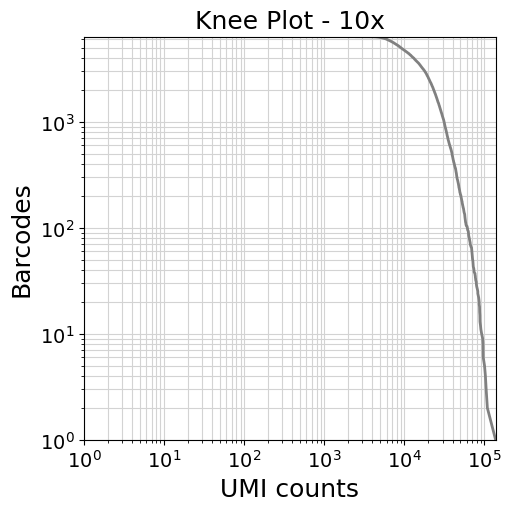

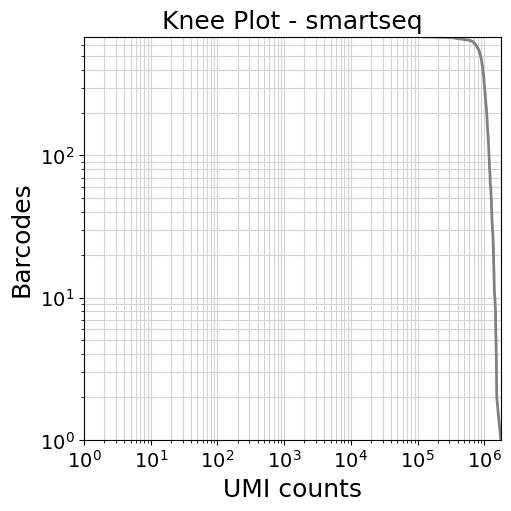

In [16]:
for technology, adata_raw in technology_to_adata_raw.items():
    print(f"Processing technology: {technology}")
    _ = cs_utils.knee_plot(adata_raw, transpose=True, title=f"Knee Plot - {technology}", out_path=os.path.join(out_dir, f"knee_plot_{technology}.png"))

In [ ]:
# technology_to_umi_cutoff = {}   #!!! update

In [18]:
for technology, adata_raw in technology_to_adata_raw.items():
    if dataset_name == "smartseq_10x":  # technology == "smartseq"
        print(f"Skipping empty droplet inference for dataset_name: smartseq_10x (filtered data only)")  # print(f"Skipping empty droplet inference for technology: {technology} (each barcode is a cell)")

        adata_raw.obs["is_empty"] = False
        adata_raw.var['empty_counts'] = 0
        technology_to_adata_raw[technology] = adata_raw
        
        continue

    print(f"Inferring empty droplets for technology: {technology}")
    #$ (1) UMI threshold
    # umi_cutoff = technology_to_umi_cutoff[technology]
    # adata_raw = cs_utils.infer_empty_droplets(adata_raw, method="threshold", umi_cutoff=umi_cutoff, verbose=verbose)  # adds adata.obs["is_empty"]

    #$ (2) EmptyDrops
    parent_dir = technology_to_adata_raw_path[technology].replace(".h5ad", "_raw_dir")
    paths = cs_utils.write_10x_like(adata_raw, parent_dir, gzip_output=True, is_empty_col="is_empty", cluster_col=None, write_raw=True, write_filtered=False)
    raw_tar_file_dir = paths["raw"]

    emptydrops_barcodes_file = os.path.join(data_dir, f"emptydrops_barcodes_{technology}.txt")
    if not os.path.exists(emptydrops_barcodes_file) or overwrite:
        !{docker} run --rm \
            -w /home/ruser/work \
            -v {cellsweep_dir}:{rver_docker_workspace} \
            josephrich98/cellsweep_tutorials:decontx.0.1.0 \
            Rscript {rver_docker_workspace}/scripts/run_emptydrops.R \
                {raw_tar_file_dir.replace(cellsweep_dir, rver_docker_workspace)} \
                {emptydrops_barcodes_file.replace(cellsweep_dir, rver_docker_workspace)}

    with open(emptydrops_barcodes_file) as f:
        emptydrops_cellular_barcodes = set(line.strip() for line in f)

    adata_raw.obs["is_empty"] = ~adata_raw.obs.index.isin(emptydrops_cellular_barcodes)

    adata_raw.var['empty_counts'] = np.array(adata_raw.X[adata_raw.obs['is_empty'].values, :].sum(axis=0)).flatten()
    technology_to_adata_raw[technology] = adata_raw

Skipping empty droplet inference for dataset_name: smartseq_10x (filtered data only)
Skipping empty droplet inference for dataset_name: smartseq_10x (filtered data only)


## cellsweep

In [19]:
technology_to_adata_cellsweep, technology_to_adata_cellsweep_empty_barcodes = {}, {}
for technology, adata_raw in technology_to_adata_raw.items():
    print(f"Denoising counts for technology: {technology}")
    adata_path_cellsweep = os.path.join(data_dir, f"adata_cellsweep_{technology}.h5ad")
    cellsweep_log_file = os.path.join(data_dir, f"cellsweep_{technology}.log")
    freeze_ambient_profile = False if dataset_name == "smartseq_10x" else True  # False if technology == "smartseq" else True
    
    if not os.path.exists(adata_path_cellsweep) or overwrite:
        adata = adata_raw.copy()
        if "celltype" not in adata.obs.columns:
            leiden_resolution = technology_to_leiden_resolution[technology]
            adata_processed_tmp = adata[~adata.obs["is_empty"]].copy()
            adata_processed_tmp = cs_utils.run_scanpy_preprocessing_and_clustering(adata_processed_tmp, min_genes=None, min_cells=None, max_mt_percentage=None, n_top_genes=2000, n_pcs=50, n_neighbors=15, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
            adata.obs["celltype"] = adata_processed_tmp.obs["leiden"].reindex(adata.obs.index).astype(str).replace("nan", "empty").astype("category")
        adata_cellsweep = denoise_count_matrix(adata, init_alpha = 0.9, beta = 0.1, adata_out=adata_path_cellsweep, freeze_ambient_profile=freeze_ambient_profile, max_iter=1500, empty_droplet_method="threshold", threads=threads, verbose=verbose, log_file=cellsweep_log_file)
    else:
        print(f"Loading existing cellsweep denoised data for technology: {technology}")
        adata_cellsweep = ad.read_h5ad(adata_path_cellsweep)
    
    adata_cellsweep_empty_barcodes = adata_cellsweep[adata_cellsweep.obs["is_empty"]].copy()
    adata_cellsweep_empty_barcodes.var_names_make_unique()
    technology_to_adata_cellsweep_empty_barcodes[technology] = adata_cellsweep_empty_barcodes

    adata_cellsweep = adata_cellsweep[~adata_cellsweep.obs["is_empty"]].copy()
    adata_cellsweep.var_names_make_unique()
    
    technology_to_adata_cellsweep[technology] = adata_cellsweep

Denoising counts for technology: 10x


15:41:49 - INFO - Adata initial shape: (6346, 62046)
15:41:49 - INFO - 'counts' layer not found in adata. Creating 'counts' layer from adata.X and normalizing total counts to 1e4. This is done by copying the raw count matrix into a new layer called 'counts' and then applying total-count normalization to ensure that each cell has the same total count (e.g., 10,000). This step is important for downstream analyses that assume normalized data.
15:41:50 - INFO - 'log1p' not found in adata.uns. Applying log1p transformation to adata.X and storing in 'log1p' layer. This transformation is commonly used to stabilize variance and make the data more normally distributed, which can improve the performance of downstream analyses such as PCA and clustering.
15:41:50 - INFO - Identifying highly variable genes using 'highly_variable_genes' function. This step identifies the top 2000 genes that show the most variability across cells, which are often the most informative for downstream analyses like clu

Logging to /home/jrich/Desktop/cellsweep/notebooks/data/smartseq_10x/cellsweep_10x.log


15:41:58 - WARNING - No empty droplets found. Setting freeze_ambient_profile=False. Ambient profile estimation may be unreliable.
15:41:59 - INFO - Number of celltypes: 18
15:41:59 - DEBUG - Number of parameters in the cellsweep model: 1,123,193 (u: 18, alpha: 6,346, beta: 1, p_k: 1,116,828)
15:41:59 - INFO - Inferring the initial gene ambient profile from cell-types. The ambient profile will be updated during training.
15:41:59 - INFO - adata.obs does not have 'cell_ambient_fraction'. Setting to `cell_ambient_fraction` argument.
15:41:59 - INFO - Performing Sparse EM with 32 Numba thread(s)
15:42:04 - INFO - EM Iter   1: ll=-162139.673 log_delta_p=inf min_alpha=0.5461 mean_alpha=0.8126 median_alpha=0.8180 max_alpha=0.9000 beta=0.098384
15:42:04 - DEBUG - 26 cells want to exceed alpha_n > 0.9. They will be excluded from update of p_k and allowed cell-type reassignment
15:42:07 - INFO - EM Iter   2: ll=-159693.539 log_delta_p=inf min_alpha=0.1772 mean_alpha=0.6631 median_alpha=0.7031 ma

Denoising counts for technology: smartseq


15:46:00 - INFO - Running PCA on the log-transformed data using 'pca' function. This step reduces the dimensionality of the data while retaining as much variance as possible. The number of principal components to compute is set to 50, and the SVD solver used is 'arpack'. Setting a random state ensures reproducibility of the results.
15:46:00 - INFO - Computing the neighborhood graph of cells using 'neighbors' function. This step constructs a graph where cells are connected to their nearest neighbors based on the PCA representation. The number of neighbors to consider is set to 15, and the number of principal components used for this step is set to 50. This graph is essential for downstream clustering and visualization.
15:46:00 - INFO - Running Leiden clustering on the neighborhood graph using 'leiden' function. This step identifies clusters of cells based on the connectivity of the graph. The 'flavor' parameter is set to 'igraph', which specifies the underlying algorithm used for clus

Logging to /home/jrich/Desktop/cellsweep/notebooks/data/smartseq_10x/cellsweep_smartseq.log


15:46:01 - INFO - EM Iter   1: ll=-8492147.168 log_delta_p=inf min_alpha=0.7517 mean_alpha=0.8076 median_alpha=0.8104 max_alpha=0.9000 beta=0.090787
15:46:01 - DEBUG - 1 cells want to exceed alpha_n > 0.9. They will be excluded from update of p_k and allowed cell-type reassignment
15:46:01 - INFO - EM Iter   2: ll=-8395568.989 log_delta_p=inf min_alpha=0.4754 mean_alpha=0.6614 median_alpha=0.6754 max_alpha=0.8871 beta=0.075600
15:46:01 - DEBUG - 0 cells want to exceed alpha_n > 0.9. They will be excluded from update of p_k and allowed cell-type reassignment
15:46:01 - INFO - EM Iter   3: ll=-8276884.771 log_delta_p=-2.0404 min_alpha=0.2180 mean_alpha=0.4930 median_alpha=0.5379 max_alpha=0.8859 beta=0.057410
15:46:01 - DEBUG - 0 cells want to exceed alpha_n > 0.9. They will be excluded from update of p_k and allowed cell-type reassignment
15:46:01 - INFO - EM Iter   4: ll=-8145677.620 log_delta_p=-2.4802 min_alpha=0.0737 mean_alpha=0.3479 median_alpha=0.4274 max_alpha=0.8931 beta=0.0390

## Analysis

### Raw vs cellsweep knee plot, scatterplots

Technology: 10x


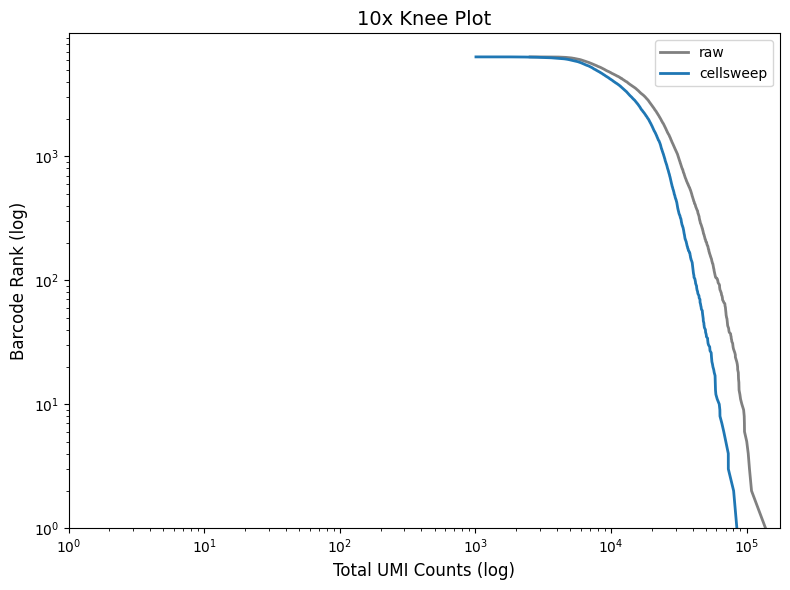

Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


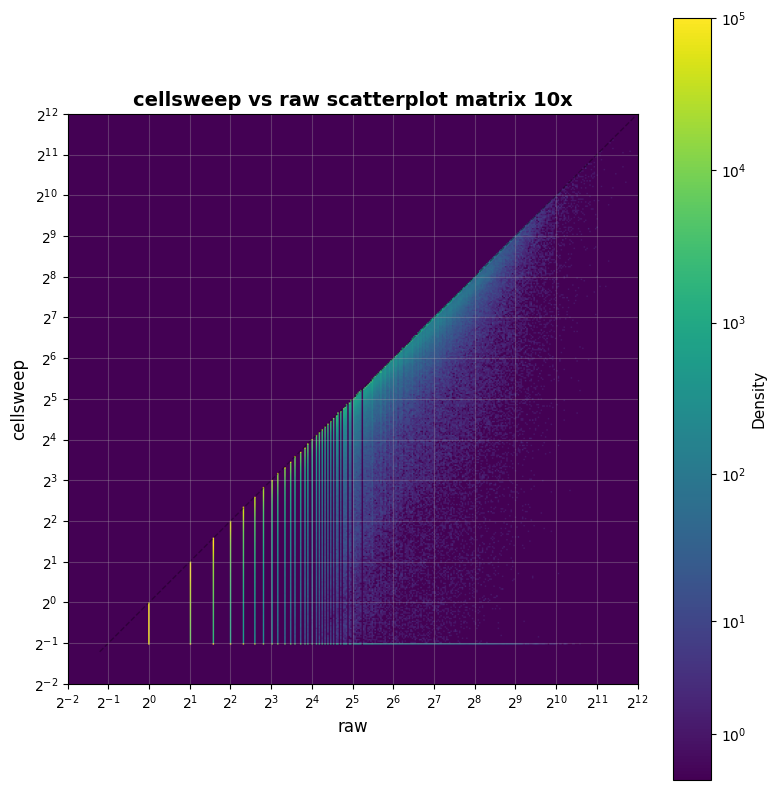

Creating scatterplot...
Calculating scatterplot...


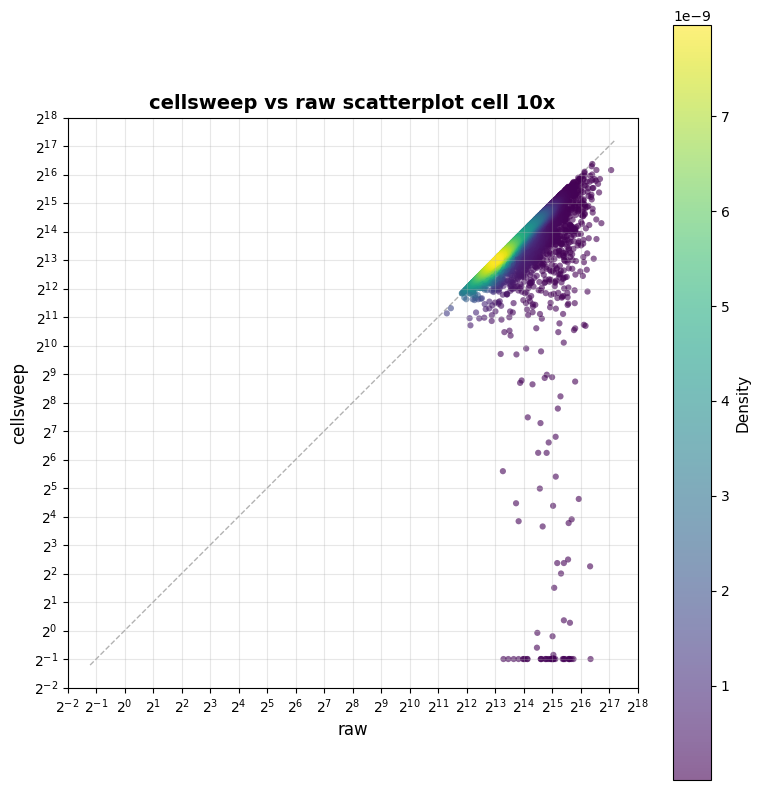

Creating scatterplot...
Calculating scatterplot...


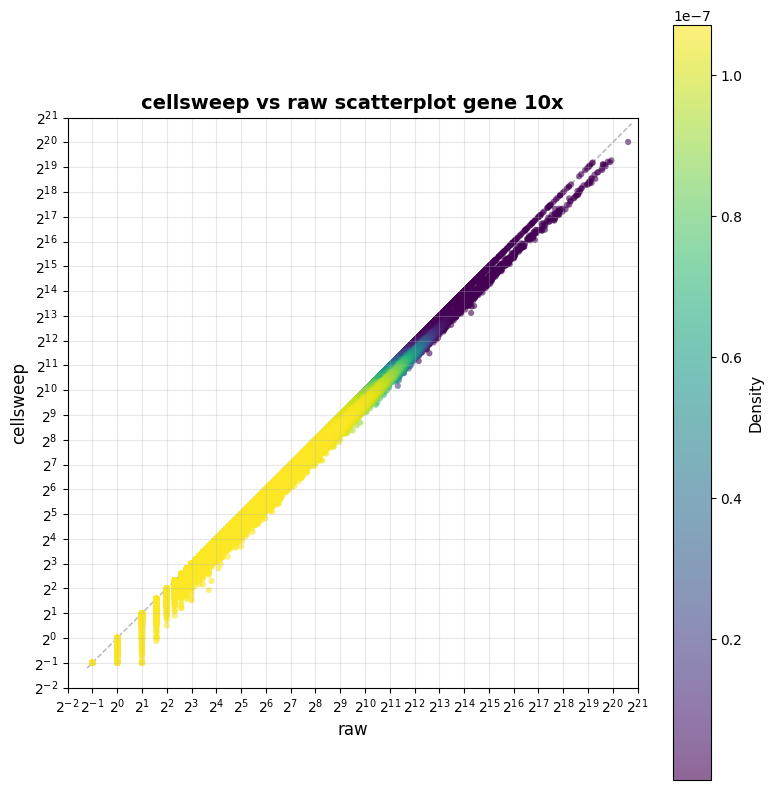

Technology: smartseq


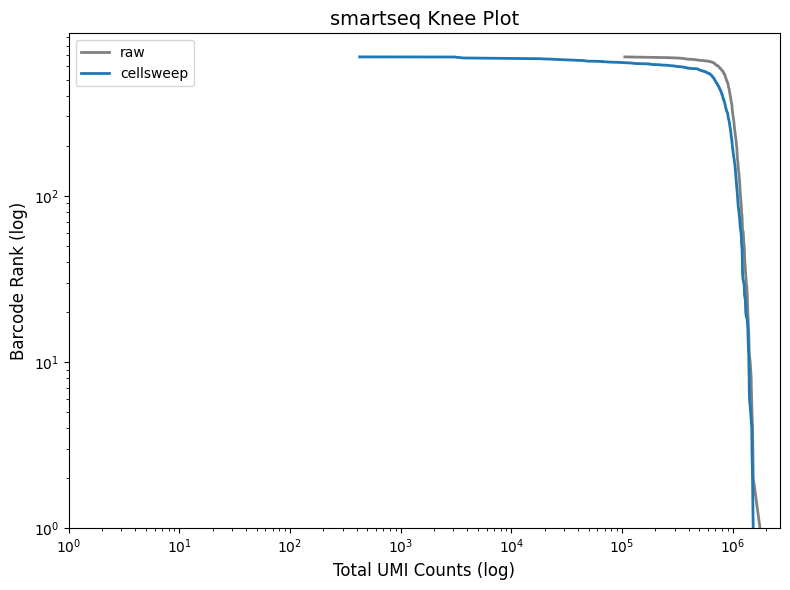

Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


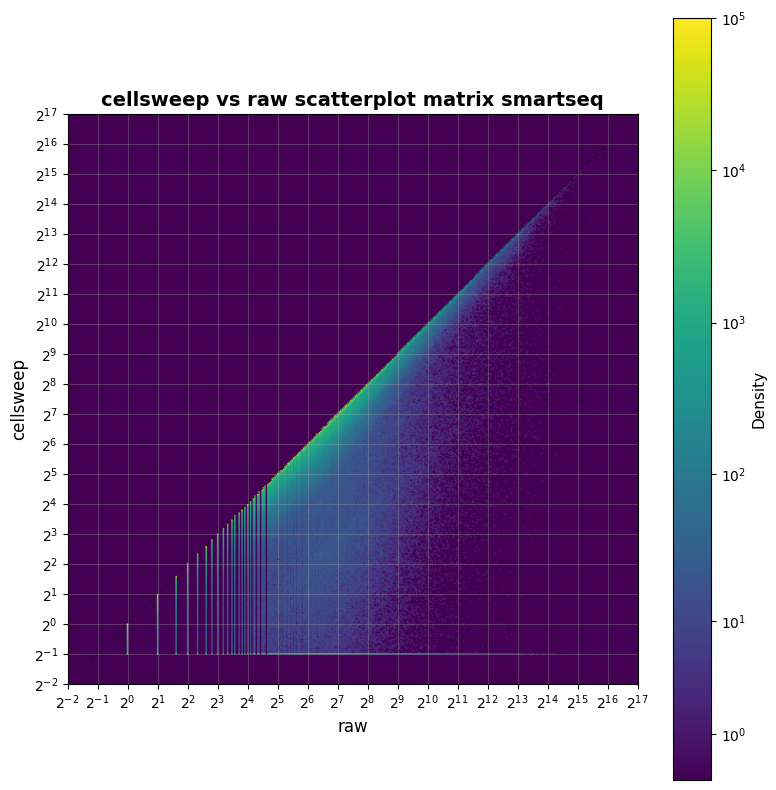

Creating scatterplot...
Calculating scatterplot...


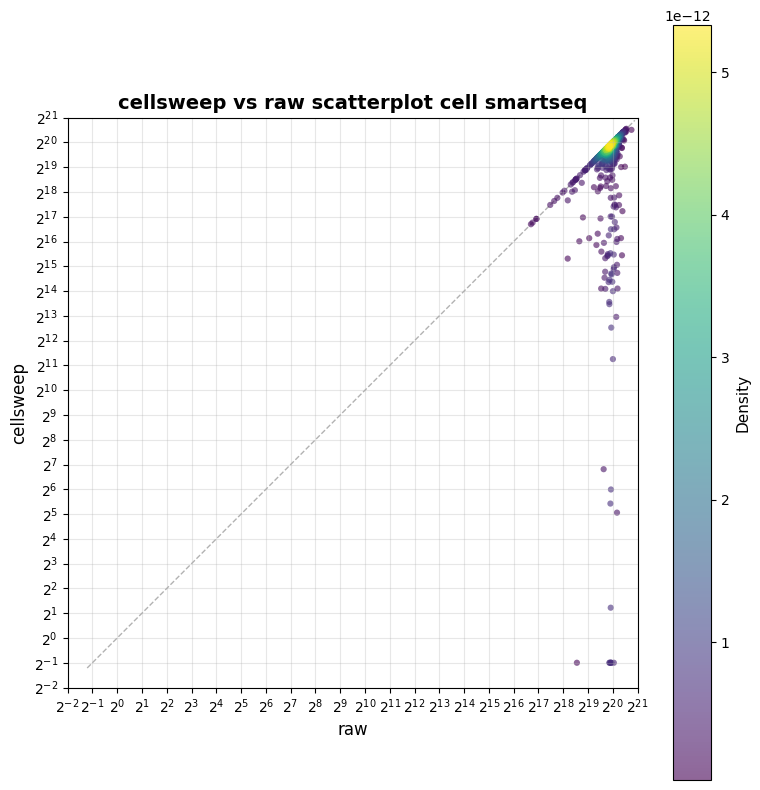

Creating scatterplot...
Calculating scatterplot...


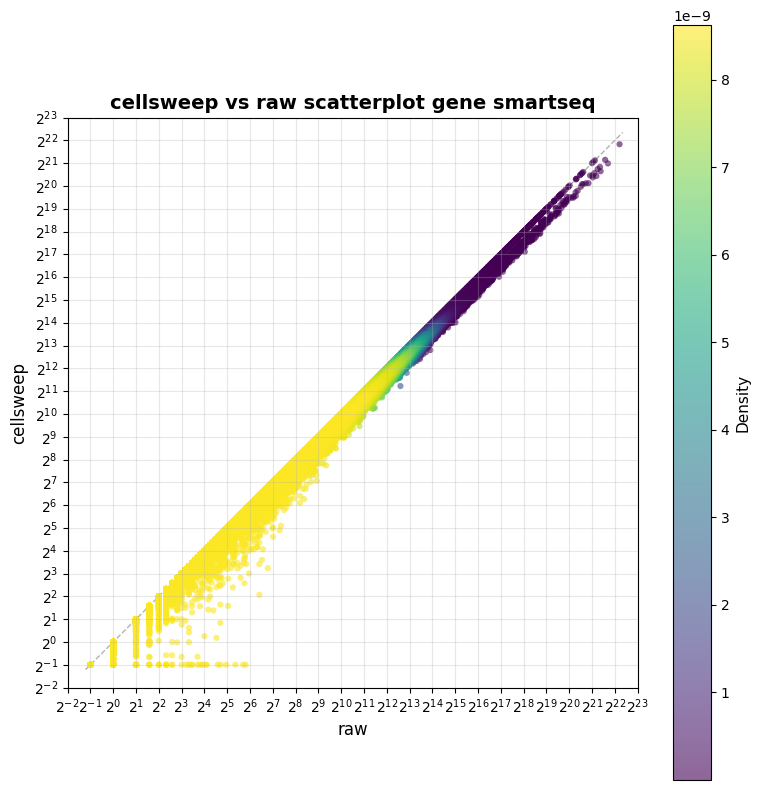

In [20]:
for technology in technologies:
    print(f"Technology: {technology}")
    adata_raw = technology_to_adata_raw[technology]
    adata_cellsweep = technology_to_adata_cellsweep[technology]
    cs_utils.plot_knee_multi([adata_raw, adata_cellsweep], labels=["raw", "cellsweep"], title=f"{technology} Knee Plot", filter_empty=True, transpose=True, out_path=os.path.join(out_dir, f"{technology}_knee_plot.png"))

    cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="matrix", density_type="scatter_with_density", scale="log", x_axis="raw", y_axis="cellsweep", title=f"cellsweep vs raw scatterplot matrix {technology}", out_path=os.path.join(out_dir, f"{technology}_matrix_expression_scatterplot.png"), show=True)
    cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="cell", density_type="scatter_with_kde", scale="log", x_axis="raw", y_axis="cellsweep", title=f"cellsweep vs raw scatterplot cell {technology}", out_path=os.path.join(out_dir, f"{technology}_cell_expression_scatterplot.png"), show=True)
    cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="gene", density_type="scatter_with_kde", scale="log", x_axis="raw", y_axis="cellsweep", title=f"cellsweep vs raw scatterplot gene {technology}", out_path=os.path.join(out_dir, f"{technology}_gene_expression_scatterplot.png"), show=True)

### Ambient hat per gene scatterplot across technologies

Creating scatterplot...
Calculating scatterplot...


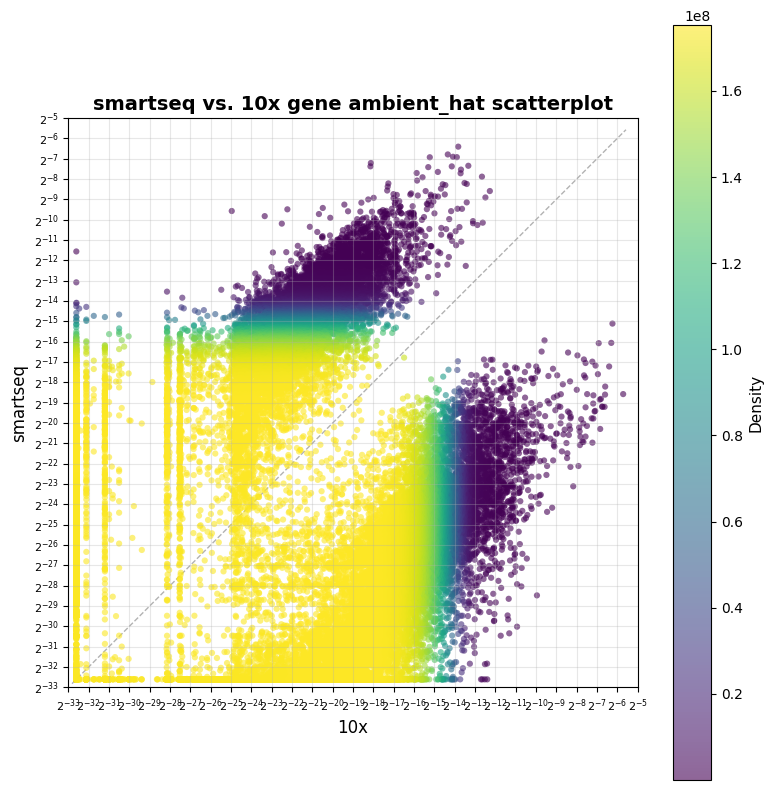

In [24]:
s = technology_to_adata_cellsweep[technology0].var["ambient_hat"]
nonzero_min = s[s > 0].min()
cs_utils.plot_matrix_scatterplot(technology_to_adata_cellsweep[technology0].var["ambient_hat"], technology_to_adata_cellsweep[technology1].var["ambient_hat"], minimum=nonzero_min, point_type="custom", density_type="scatter_with_kde", scale="log", title=f"{technology1} vs. {technology0} gene ambient_hat scatterplot", x_axis=technology0, y_axis=technology1, tick_labelsize=8, out_path=os.path.join(out_dir, f"{technology0}_vs_{technology1}_ambient_hat_scatterplot.png"), show=True)

### Ambient fraction per cell histogram across technologies

10x cell contamination AUC: 63.45999999999986
smartseq cell contamination AUC: 6.849999999999989


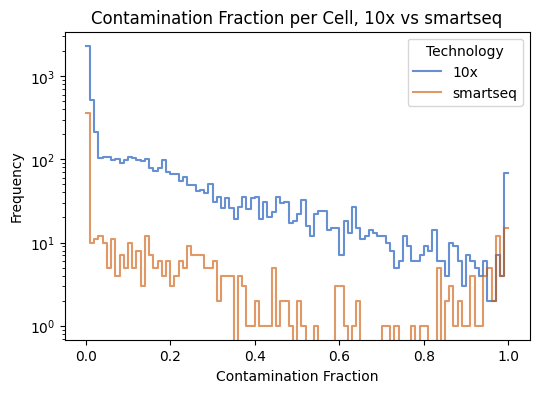

In [22]:
cs_utils.plot_multi_histogram(technology_to_adata_cellsweep[technology0].obs, technology_to_adata_cellsweep[technology1].obs, plotting_column="alpha_hat", df1_name=technology0, df2_name=technology1, out_path=os.path.join(out_dir, f"{technology0}_vs_{technology1}_cell_empty_fraction_histogram.png"), show=True)